# 07 - Robustness: daily TED (TEDRATE)

The OECD interbank rates behind `levels.csv` are monthly averages, so the TED
used in notebooks 02-06 is a step function with almost no day-to-day variation,
the funding-stress spikes of 2008 and 2020 are averaged away, which attenuates
the TED coefficient towards zero. This notebook repeats the baseline regression
and the break search with the canonical **daily** TED spread (FRED `TEDRATE`,
3M USD LIBOR minus the 3M T-bill). TEDRATE ends on 2022-01-21 with the LIBOR
cessation, so every comparison runs on the common sample up to that date.

## Setup

In [1]:
import os

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from fredapi import Fred

import safe_haven as sh
from safe_haven import CURRENCIES, REGRESSORS, DATA_DIR, FIG_DIR, PAPER_DIR, bai_perron

CUTOFF = "2022-01-21"          # last TEDRATE observation (LIBOR cessation)

FIG_DIR.mkdir(exist_ok=True)
PAPER_DIR.mkdir(exist_ok=True)

## Download daily TED

Saved to `data/ted_daily.csv` so later analysis cells work from the snapshot.

In [2]:
load_dotenv(sh.ROOT / ".env")

# Re-download only when a FRED key is available; otherwise fall back to the
# committed data/ted_daily.csv (TEDRATE is discontinued, so the series is final).
if "FRED_API_KEY" in os.environ:
    fred = Fred(api_key=os.environ["FRED_API_KEY"])
    ted_daily_pp = fred.get_series("TEDRATE", observation_start="2000-01-01",
                                   observation_end=CUTOFF).rename("TED_daily")
    ted_daily_pp.rename_axis("date").to_csv(DATA_DIR / "ted_daily.csv")
else:
    print("No FRED_API_KEY - using the committed data/ted_daily.csv")
    ted_daily_pp = pd.read_csv(DATA_DIR / "ted_daily.csv", index_col="date",
                               parse_dates=True)["TED_daily"]
print(f"{len(ted_daily_pp)} observations, "
      f"{ted_daily_pp.index.min().date()} to {ted_daily_pp.index.max().date()}")

5755 observations, 2000-01-03 to 2022-01-21


## Load and construct variables

Same construction as notebook 02; the TED enters in two variants (monthly OECD,
daily TEDRATE), everything else is identical.

In [3]:
data = sh.load_data()
levels = data.levels

ted_daily_pp = pd.read_csv(DATA_DIR / "ted_daily.csv", index_col="date",
                           parse_dates=True)["TED_daily"]
TED = {"monthly": data.ted, "daily": ted_daily_pp / 360}

def model_frame(cur, ted):
    """Common sample for a fair comparison between the two TED series."""
    return data.model_frame(cur, ted=TED[ted]).loc[:CUTOFF]

## Daily vs monthly TED

The monthly series steps through the 2008 and 2020 spikes that the daily series
resolves.

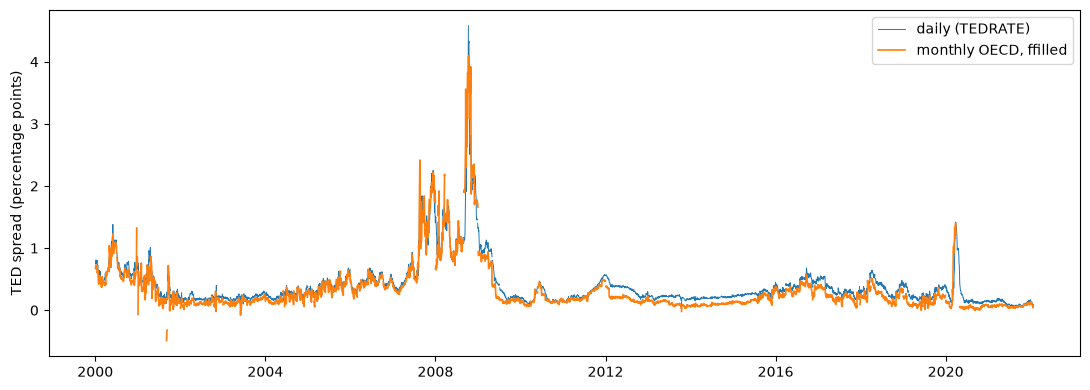

In [4]:
ted_monthly_pp = (levels["US_3M"] - levels["TBILL_3M"]).loc[:CUTOFF]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ted_daily_pp.index, ted_daily_pp, lw=0.7, label="daily (TEDRATE)")
ax.plot(ted_monthly_pp.index, ted_monthly_pp, lw=1.2, label="monthly OECD, ffilled")
ax.set_ylabel("TED spread (percentage points)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "ted_daily_vs_monthly.png", dpi=300, bbox_inches="tight")
plt.show()

## Baseline OLS with both TED variants

Only the TED row should move; the cell below checks that the other coefficients
stay put.

In [5]:
results = {(cur, ted): smf.ols("excess ~ SP500 + UST10Y + fxvol + TED + VIX",
                               data=model_frame(cur, ted)).fit(
                                   cov_type="HAC", cov_kwds={"maxlags": 2})
           for cur in CURRENCIES for ted in TED}

comparison = pd.DataFrame(
    {(cur, ted): {"TED coef": r.params["TED"], "TED t": r.tvalues["TED"],
                  "R2": r.rsquared, "N": int(r.nobs)}
     for (cur, ted), r in results.items()}).T.round(3)
comparison

TED coef  TED t     R2       N
CHF monthly    -0.061 -0.566  0.030  5210.0
    daily      -0.065 -0.562  0.031  5154.0
EUR monthly    -0.086 -0.740  0.015  5210.0
    daily      -0.067 -0.542  0.015  5154.0
GBP monthly    -0.222 -1.701  0.020  5210.0
    daily      -0.214 -1.720  0.019  5154.0
JPY monthly     0.103  0.807  0.139  4706.0
    daily       0.113  0.883  0.140  4654.0

In [6]:
shift = pd.Series(
    {cur: (results[(cur, "daily")].params - results[(cur, "monthly")].params)
          .drop(["Intercept", "TED"]).abs().max()
     for cur in CURRENCIES}, name="max |change| in other coefficients")
shift.round(4)

CHF    0.0004
EUR    0.0003
GBP    0.0001
JPY    0.0007
Name: max |change| in other coefficients, dtype: float64

## Break detection with daily TED

Same exact search as notebook 03, run once per TED variant on the common
sample, so differences in break dates are attributable to the TED measurement.

In [7]:
break_dates = {}
for ted in TED:
    for cur in CURRENCIES:
        df = model_frame(cur, ted)
        bkps, _ = bai_perron(df)
        break_dates[(cur, ted)] = ", ".join(
            df.index[i - 1].date().isoformat() for i in bkps[:-1]) or "none"
pd.Series(break_dates, name="break dates").sort_index()

CHF  daily      2009-03-24, 2013-04-18
     monthly    2009-03-24, 2013-04-18
EUR  daily      2009-01-07, 2013-03-28
     monthly    2009-01-07, 2013-03-28
GBP  daily                  2008-10-20
     monthly                2008-10-20
JPY  daily                  2006-06-29
     monthly                2006-06-29
Name: break dates, dtype: str

## Export to LaTeX

In [8]:
L = [r"\begin{table}[H]", r"\centering",
     r"\caption{Robustness: baseline regression with the monthly OECD TED versus "
     r"the daily TED spread (FRED TEDRATE), common sample 2000--2022-01. "
     r"Newey-West (HAC) $t$-statistics, lag 2.}",
     r"\label{tab:tedrobust}", r"\begin{tabular}{llrrrr}", r"\toprule",
     r"Currency & TED series & TED coef.\ & $t$ & $R^2$ & $N$ \\", r"\midrule"]
for cur in CURRENCIES:
    for ted in ["monthly", "daily"]:
        r = results[(cur, ted)]
        name = cur if ted == "monthly" else ""
        L.append(f"{name} & {ted} & ${r.params['TED']:.3f}$ & ${r.tvalues['TED']:.1f}$ & "
                 f"${r.rsquared:.3f}$ & {int(r.nobs)} " + r"\\")
    if cur != CURRENCIES[-1]:
        L.append(r"\midrule")
L += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
(PAPER_DIR / "ted_robustness.tex").write_text("\n".join(L))
print(f"Wrote {PAPER_DIR / 'ted_robustness.tex'}")

Wrote /workspaces/safe-haven-dlm-public/paper/ted_robustness.tex
